# Sensibilidad de cohorte y validación del endpoint

## Objetivo 

El objetivo de este notebook es evaluar la robustez de la cohorte preliminar y del endpoint de tiempo hasta entrada de genéricos.

En los notebooks anteriores se construyó el pipeline principal del proyecto:

1. `01_ingesta_orangebook_drugsfda.ipynb`  
   - lectura de Orange Book y Drugs@FDA;
   - normalización de llaves;
   - construcción de unidades ingrediente--forma--ruta;
   - identificación preliminar del primer genérico comparable;
   - estimación de una curva Kaplan--Meier global.

2. `02_patentes_exclusividades_endpoint.ipynb`  
   - integración de patentes;
   - integración de exclusividades regulatorias;
   - curvas Kaplan--Meier por subgrupos regulatorios.

3. `03_modelos_supervivencia_cox_aft.ipynb`  
   - modelos Cox proporcionales de riesgos;
   - modelos Cox ajustados y estratificados por ruta;
   - modelos AFT Weibull y Log-Logistic;
   - comparación de modelos.

Los resultados preliminares sugieren que las patentes de sustancia y producto se asocian con una entrada más tardía de genéricos, mientras que la ruta de administración tiene un papel importante en la dinámica del tiempo hasta genérico.

Sin embargo, antes de interpretar estos resultados con más fuerza, es necesario revisar la sensibilidad del análisis frente a distintas decisiones de construcción de cohorte.


La base construida hasta ahora trabaja con una unidad preliminar:


ingrediente activo + forma farmacéutica + ruta de administración

y define el evento como la primera aprobación ANDA comparable con la misma combinación.

Esta definición es razonable para un piloto, pero puede incluir casos problemáticos, por ejemplo:

* productos que no son verdaderas nuevas entidades moleculares;
* reformulaciones;
* cambios de concentración;
* cambios OTC;
* productos descontinuados;
* productos con genéricos muy tempranos;
* productos cuya dinámica de competencia no corresponde claramente a una NME;
* combinaciones donde la ruta o forma farmacéutica está codificada de forma muy específica.

Por ello, este notebook buscará evaluar qué tan robustos son los resultados bajo reglas alternativas.



## Análisis de sensibilidad propuestos

En este notebook se construirán varias versiones de la cohorte:

### 1. Cohorte base

La base principal generada en el notebook anterior:

```text
survival_analysis_v2_patents_exclusivities.parquet
```

### 2. Cohorte RX-only

Se excluirán productos OTC o descontinuados si la información necesaria está disponible. Esta versión busca concentrarse en productos de prescripción activa.

### 3. Cohorte sin eventos muy tempranos

Se excluirán eventos con tiempo a genérico menor a cierto umbral, por ejemplo:

```text
time_to_generic_years < 1
```

La motivación es que una entrada genérica extremadamente temprana puede indicar que la unidad no corresponde a una innovación original, sino a una presentación posterior o una reclasificación.

### 4. Cohorte con seguimiento mínimo

Se revisarán cortes según año de aprobación, por ejemplo:

```text
1998--2015
```

en lugar de 1998--2018, para dar más tiempo de seguimiento a todas las unidades.

### 5. Cohorte con evento basado en TE code

Si la información está disponible, se evaluará una versión más estricta del evento considerando solo genéricos con códigos de equivalencia terapéutica que comiencen con `A`, por ejemplo `AB`, `AT`, `AA`, etc.



## Preguntas 

Este notebook busca responder:

1. ¿Cuántas unidades se pierden bajo cada regla de sensibilidad?
2. ¿Cambia la proporción de eventos?
3. ¿Cambia la mediana Kaplan--Meier del tiempo hasta genérico?
4. ¿Se mantiene la asociación de patentes de sustancia y producto?
5. ¿El modelo Log-Logistic AFT sigue siendo consistente?
6. ¿Los resultados son sensibles a eventos muy tempranos o cohortes recientes?


## Salidas esperadas

Al final del notebook se espera generar:

```text
data_intermediate/sensitivity_cohorts/
```

con bases como:

```text
survival_v2_base.parquet
survival_v2_no_early_events.parquet
survival_v2_1998_2015.parquet
survival_v2_te_a_only.parquet
```

Se guardarán tablas como:

```text
tables/sensitivity_cohort_summary.csv
tables/sensitivity_model_summary.csv
```

y figuras como:

```text
figures/km_sensitivity_cohorts.png
figures/sensitivity_patent_effects.png
```


## Nota de interpretación

Este notebook no reemplaza la definición final de cohorte. Su objetivo es identificar qué decisiones afectan más los resultados.

Si los resultados principales se mantienen bajo varias reglas razonables, tendremos más confianza en la robustez del análisis. Si cambian mucho, eso indicará que debemos refinar la definición de cohorte antes de avanzar hacia redacción de resultados.




## Preparación del entorno y carga de bases necesarias

En esta primera celda se cargan las librerías necesarias y se leen dos bases:

1. `survival_analysis_v2_patents_exclusivities.parquet`, que contiene el endpoint, patentes y exclusividades.
2. `survival_analysis_v1.parquet`, si se requiere contrastar variables originales del endpoint.

La base principal para sensibilidad será `survival_v2`.

También se crearán carpetas de salida específicas para guardar las cohortes alternativas.

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

# Rutas principales

PROJECT_DIR = Path.cwd()

DATA_INTERMEDIATE_DIR = PROJECT_DIR / "data_intermediate"
DATA_FINAL_DIR = PROJECT_DIR / "data_final"
FIGURES_DIR = PROJECT_DIR / "figures"
TABLES_DIR = PROJECT_DIR / "tables"

SENSITIVITY_DIR = DATA_INTERMEDIATE_DIR / "sensitivity_cohorts"

for folder in [DATA_INTERMEDIATE_DIR, DATA_FINAL_DIR, FIGURES_DIR, TABLES_DIR, SENSITIVITY_DIR]:
    folder.mkdir(exist_ok=True)


survival_v2_path = DATA_INTERMEDIATE_DIR / "survival_analysis_v2_patents_exclusivities.parquet"
survival_v1_path = DATA_INTERMEDIATE_DIR / "survival_analysis_v1.parquet"

survival_v2 = pd.read_parquet(survival_v2_path)
survival_v1 = pd.read_parquet(survival_v1_path)

print("=" * 80)
print("Bases cargadas correctamente")
print("=" * 80)

print(f"survival_v2: {survival_v2.shape[0]:,} filas | {survival_v2.shape[1]:,} columnas")
print(f"survival_v1: {survival_v1.shape[0]:,} filas | {survival_v1.shape[1]:,} columnas")

print("\nRuta survival_v2:")
print(survival_v2_path)

print("\nRuta survival_v1:")
print(survival_v1_path)

print("\nResumen del endpoint en survival_v2:")
display(
    survival_v2[["time_to_generic_years", "event", "approval_year"]]
    .describe()
)

print("\nEventos y censuras:")
display(
    survival_v2["event"]
    .value_counts()
    .rename_axis("event")
    .reset_index(name="n")
)

print("\nColumnas disponibles en survival_v2:")
print(list(survival_v2.columns))

Bases cargadas correctamente
survival_v2: 1,439 filas | 46 columnas
survival_v1: 1,439 filas | 23 columnas

Ruta survival_v2:
/Users/juanalbertomartinez/Desktop/Patente/data_intermediate/survival_analysis_v2_patents_exclusivities.parquet

Ruta survival_v1:
/Users/juanalbertomartinez/Desktop/Patente/data_intermediate/survival_analysis_v1.parquet

Resumen del endpoint en survival_v2:


,time_to_generic_years,event,approval_year
count,1439.000000,1439.000000,1439.000000
mean,11.285602,0.596942,2008.244614
std,5.868447,0.490683,6.381470
min,0.093087,0.000000,1998.000000
25%,7.411362,0.000000,2003.000000
50%,10.313484,1.000000,2008.000000
75%,14.506502,1.000000,2014.000000
max,28.246407,1.000000,2018.000000



Eventos y censuras:


,event,n
0,1,859
1,0,580



Columnas disponibles en survival_v2:
['ingredient', 'dosage_form', 'route', 'nme_approval_date', 'approval_year', 'innovator_appl_no', 'innovator_product_no', 'innovator_trade_name', 'first_generic_approval_date', 'first_generic_appl_no', 'first_generic_product_no', 'first_generic_trade_name', 'first_generic_te_code', 'event', 'end_date', 'time_to_generic_years', 'n_nda_products', 'n_nda_applications', 'n_anda_products_total', 'n_anda_applications_total', 'ingredient_key', 'dosage_form_key', 'route_key', 'n_patents', 'n_patent_records', 'patent_expiry_min', 'patent_expiry_max', 'has_drug_substance_patent', 'has_drug_product_patent', 'has_patent_use_code', 'has_delist_flag', 'patent_use_codes', 'patent_numbers', 'has_patent', 'n_exclusivities', 'n_exclusivity_records', 'exclusivity_expiry_min', 'exclusivity_expiry_max', 'exclusivity_codes', 'has_exclusivity', 'has_nce_like_exclusivity', 'has_orphan_like_exclusivity', 'has_pediatric_like_exclusivity', 'years_to_patent_expiry_min', 'year



Las bases necesarias para el análisis de sensibilidad se cargaron correctamente.

La base principal `survival_v2` contiene:

- 1,439 unidades ingrediente--forma--ruta;
- 46 columnas;
- información del endpoint;
- variables de patentes;
- variables de exclusividades;
- variables temporales derivadas.

La base `survival_v1` también contiene 1,439 unidades, pero solo 23 columnas. Esta base puede servir como referencia para comparar el endpoint original antes de integrar patentes y exclusividades.

El endpoint en `survival_v2` coincide con los notebooks anteriores:

- 859 eventos observados;
- 580 unidades censuradas;
- tiempo mediano observado de aproximadamente 10.31 años;
- años de aprobación entre 1998 y 2018.

También se confirmó que `survival_v2` contiene las variables necesarias para construir cohortes alternativas, incluyendo:

- `time_to_generic_years`;
- `event`;
- `approval_year`;
- `first_generic_te_code`;
- `has_patent`;
- `has_drug_substance_patent`;
- `has_drug_product_patent`;
- `has_exclusivity`;
- `route`;
- `dosage_form`.

El siguiente paso será construir una función que resuma cualquier cohorte de sensibilidad de forma estándar. Esto permitirá comparar fácilmente tamaño, eventos, censura, mediana de seguimiento y mediana Kaplan--Meier.

## Funciones auxiliares para resumir cohortes de sensibilidad

Antes de construir las cohortes alternativas, definiremos funciones auxiliares para resumir cualquier versión de la base.

Para cada cohorte se calcularán:

- número de unidades;
- número de eventos;
- número de censuras;
- proporción de eventos;
- año mínimo y máximo de aprobación;
- mediana del tiempo observado;
- mediana del tiempo entre eventos observados;
- mediana Kaplan--Meier del tiempo hasta genérico.

La mediana Kaplan--Meier es especialmente importante porque toma en cuenta la censura, a diferencia de la mediana simple del tiempo observado.

Estas funciones permitirán comparar de manera sistemática la cohorte base contra las versiones filtradas.

In [6]:
# Funciones auxiliares para resumir cohortes de sensibilidad

try:
    from lifelines import KaplanMeierFitter
except ImportError as e:
    raise ImportError(
        "La librería 'lifelines' no está instalada. "
        "Instálala con: pip install lifelines"
    ) from e


def km_median_time(df, duration_col="time_to_generic_years", event_col="event"):
    """
    Calcula la mediana Kaplan--Meier para una cohorte.
    """
    if df.empty:
        return np.nan
    
    kmf = KaplanMeierFitter()
    kmf.fit(
        durations=df[duration_col],
        event_observed=df[event_col]
    )
    return kmf.median_survival_time_


def summarize_cohort(df, cohort_name):
    """
    Resume una cohorte de sensibilidad.
    """
    n_units = len(df)
    n_events = int(df["event"].sum()) if n_units > 0 else 0
    n_censored = int((df["event"] == 0).sum()) if n_units > 0 else 0
    
    out = {
        "cohort": cohort_name,
        "n_units": n_units,
        "n_events": n_events,
        "n_censored": n_censored,
        "event_rate": n_events / n_units if n_units > 0 else np.nan,
        "approval_year_min": df["approval_year"].min() if n_units > 0 else np.nan,
        "approval_year_max": df["approval_year"].max() if n_units > 0 else np.nan,
        "median_observed_time": df["time_to_generic_years"].median() if n_units > 0 else np.nan,
        "median_events_only": (
            df.loc[df["event"].eq(1), "time_to_generic_years"].median()
            if n_events > 0 else np.nan
        ),
        "km_median_time": km_median_time(df) if n_units > 0 else np.nan,
        "n_has_patent": int(df["has_patent"].sum()) if "has_patent" in df.columns and n_units > 0 else np.nan,
        "n_has_drug_substance_patent": int(df["has_drug_substance_patent"].sum()) if "has_drug_substance_patent" in df.columns and n_units > 0 else np.nan,
        "n_has_drug_product_patent": int(df["has_drug_product_patent"].sum()) if "has_drug_product_patent" in df.columns and n_units > 0 else np.nan,
        "n_has_exclusivity": int(df["has_exclusivity"].sum()) if "has_exclusivity" in df.columns and n_units > 0 else np.nan,
    }
    
    return out


# Probar con cohorte base
base_summary = pd.DataFrame([
    summarize_cohort(survival_v2, "base")
])

print("=" * 80)
print("Resumen de prueba: cohorte base")
print("=" * 80)

base_summary

Resumen de prueba: cohorte base


,cohort,n_units,n_events,n_censored,event_rate,approval_year_min,approval_year_max,median_observed_time,median_events_only,km_median_time,n_has_patent,n_has_drug_substance_patent,n_has_drug_product_patent,n_has_exclusivity
0,base,1439,859,580,0.596942,1998,2018,10.313484,8.372348,12.791239,589,264,504,150




La función auxiliar para resumir cohortes funcionó correctamente.

Para la cohorte base se recuperan los mismos valores observados en los notebooks anteriores:

- 1,439 unidades ingrediente--forma--ruta;
- 859 eventos observados;
- 580 observaciones censuradas;
- tasa de evento de aproximadamente 59.7%;
- años de aprobación entre 1998 y 2018;
- mediana simple del tiempo observado de 10.31 años;
- mediana del tiempo entre eventos observados de 8.37 años;
- mediana Kaplan--Meier de 12.79 años.

Además, la cohorte base contiene:

- 589 unidades con al menos una patente listada;
- 264 unidades con patente de sustancia;
- 504 unidades con patente de producto;
- 150 unidades con exclusividad listada.

Esta función será útil porque permitirá comparar de manera homogénea todas las cohortes alternativas. El siguiente paso será construir varias versiones filtradas de la cohorte y resumirlas en una sola tabla.

## Construcción de cohortes alternativas de sensibilidad

En esta sección construiremos varias versiones de la cohorte para evaluar la sensibilidad del análisis.

Las cohortes serán:

### Cohorte base

La base completa `survival_v2`, sin filtros adicionales.

### Cohorte 1998--2015

Se restringe el periodo de aprobación a 1998--2015. Esta versión da más tiempo de seguimiento a todas las unidades y reduce la censura de productos muy recientes.

### Cohorte sin eventos tempranos menores a 1 año

Se excluyen unidades con evento observado antes de 1 año. Estos casos pueden corresponder a productos que no son verdaderas innovaciones iniciales, sino reformulaciones, switches OTC, nuevas presentaciones o aprobaciones para las que ya existía competencia genérica cercana.

### Cohorte sin eventos tempranos menores a 2 años

Es una versión más estricta del filtro anterior.

### Cohorte TE-A only

Se conservarán todos los censurados, pero para los eventos observados se requerirá que el primer genérico tenga un código de equivalencia terapéutica que comience con `A`, por ejemplo `AB`, `AA`, `AT` u otros códigos equivalentes.

En esta versión, los eventos cuyo primer genérico no tiene TE code tipo `A` serán reclasificados como censurados en la fecha de corte. Esta es una regla más conservadora para definir entrada genérica terapéuticamente equivalente.

In [8]:
# Construcción de cohortes alternativas de sensibilidad


# Fecha de corte usada para censura
STUDY_CUTOFF_DATE = pd.to_datetime(survival_v2["end_date"]).max()

print("Fecha de corte del estudio:", STUDY_CUTOFF_DATE.date())

# Asegurar fechas
survival_v2 = survival_v2.copy()
survival_v2["nme_approval_date"] = pd.to_datetime(survival_v2["nme_approval_date"], errors="coerce")
survival_v2["end_date"] = pd.to_datetime(survival_v2["end_date"], errors="coerce")
survival_v2["first_generic_approval_date"] = pd.to_datetime(
    survival_v2["first_generic_approval_date"], errors="coerce"
)

# Cohorte base
cohort_base = survival_v2.copy()

# Cohorte 1998--2015
cohort_1998_2015 = survival_v2.loc[
    survival_v2["approval_year"].between(1998, 2015)
].copy()

# Cohorte sin eventos tempranos menores a 1 año
cohort_no_early_1y = survival_v2.loc[
    ~(
        survival_v2["event"].eq(1)
        & (survival_v2["time_to_generic_years"] < 1)
    )
].copy()

# Cohorte sin eventos tempranos menores a 2 años
cohort_no_early_2y = survival_v2.loc[
    ~(
        survival_v2["event"].eq(1)
        & (survival_v2["time_to_generic_years"] < 2)
    )
].copy()

# Cohorte TE-A only
cohort_te_a_only = survival_v2.copy()

# Identificar eventos con TE code que comienza con A
te_code = cohort_te_a_only["first_generic_te_code"].fillna("").astype(str).str.upper().str.strip()
is_te_a_event = cohort_te_a_only["event"].eq(1) & te_code.str.startswith("A")

# Eventos observados que no cumplen TE-A
event_not_te_a = cohort_te_a_only["event"].eq(1) & (~is_te_a_event)

# Reclasificar como censurados en la fecha de corte
cohort_te_a_only.loc[event_not_te_a, "event"] = 0
cohort_te_a_only.loc[event_not_te_a, "end_date"] = STUDY_CUTOFF_DATE

cohort_te_a_only["time_to_generic_years"] = (
    (pd.to_datetime(cohort_te_a_only["end_date"]) - pd.to_datetime(cohort_te_a_only["nme_approval_date"]))
    .dt.days / 365.25
)


# Diccionario de cohortes
sensitivity_cohorts = {
    "base": cohort_base,
    "approval_1998_2015": cohort_1998_2015,
    "no_early_events_lt_1y": cohort_no_early_1y,
    "no_early_events_lt_2y": cohort_no_early_2y,
    "te_a_only": cohort_te_a_only,
}

# Resumir cohortes
sensitivity_cohort_summary = pd.DataFrame([
    summarize_cohort(df, name)
    for name, df in sensitivity_cohorts.items()
])

print("=" * 80)
print("Resumen de cohortes de sensibilidad")
print("=" * 80)

display(sensitivity_cohort_summary)

# Revisar cuántos eventos se reclasificaron en TE-A only
print("\nEventos originales que no cumplen TE-A y fueron reclasificados como censura:")
print(int(event_not_te_a.sum()))

print("\nDistribución de TE codes en eventos originales:")
display(
    survival_v2.loc[survival_v2["event"].eq(1), "first_generic_te_code"]
    .fillna("MISSING")
    .astype(str)
    .str.upper()
    .str.strip()
    .value_counts()
    .head(20)
    .rename_axis("first_generic_te_code")
    .reset_index(name="n")
)

Fecha de corte del estudio: 2026-04-09
Resumen de cohortes de sensibilidad


,cohort,n_units,n_events,n_censored,event_rate,approval_year_min,approval_year_max,median_observed_time,median_events_only,km_median_time,n_has_patent,n_has_drug_substance_patent,n_has_drug_product_patent,n_has_exclusivity
0,base,1439,859,580,0.596942,1998,2018,10.313484,8.372348,12.791239,589,264,504,150
1,approval_1998_2015,1192,799,393,0.670302,1998,2015,11.540041,8.843258,12.657084,398,163,324,92
2,no_early_events_lt_1y,1417,837,580,0.590685,1998,2018,10.403833,8.594114,13.032170,587,264,502,150
3,no_early_events_lt_2y,1398,818,580,0.585122,1998,2018,10.468172,8.788501,13.273101,587,264,502,150
4,te_a_only,1439,711,728,0.494093,1998,2018,11.189596,8.714579,15.184120,589,264,504,150



Eventos originales que no cumplen TE-A y fueron reclasificados como censura:
148

Distribución de TE codes en eventos originales:


,first_generic_te_code,n
0,AB,501
1,MISSING,148
2,AP,115
3,AA,37
4,AT,22
5,AB1,17
6,AN,6
7,AP1,3
8,AT1,3
9,AB2,2




La construcción de cohortes alternativas se realizó correctamente.

La cohorte base conserva 1,439 unidades, con 859 eventos y una mediana Kaplan--Meier de 12.79 años.

La cohorte restringida a aprobaciones 1998--2015 reduce el tamaño a 1,192 unidades, pero aumenta la tasa de eventos de 59.7% a 67.0%. Esto es esperable, porque al excluir aprobaciones recientes se reduce la censura asociada a menor tiempo de seguimiento. La mediana Kaplan--Meier se mantiene muy cercana a la base, con aproximadamente 12.66 años.

Las cohortes que excluyen eventos tempranos muestran cambios moderados:

- al excluir eventos menores a 1 año, quedan 1,417 unidades y la mediana KM sube a 13.03 años;
- al excluir eventos menores a 2 años, quedan 1,398 unidades y la mediana KM sube a 13.27 años.

Esto indica que los eventos muy tempranos sí reducen ligeramente la mediana estimada, pero no cambian radicalmente la estructura general del endpoint.

La cohorte `te_a_only` es la más restrictiva respecto a la definición del evento. En esta versión se reclasificaron 148 eventos originales como censura porque el primer genérico no tenía un TE code que comenzara con `A`. Como resultado:

- los eventos bajan de 859 a 711;
- la tasa de evento baja de 59.7% a 49.4%;
- la mediana Kaplan--Meier aumenta de 12.79 a 15.18 años.

Esto muestra que la definición del evento basada en TE code tiene un impacto importante. La diferencia se debe principalmente a eventos con TE code faltante, ya que 148 eventos originales aparecen como `MISSING`.

La distribución de TE codes muestra que el código más frecuente es `AB`, seguido por eventos sin TE code, `AP`, `AA` y `AT`. Para el análisis principal podríamos mantener la definición amplia, pero para sensibilidad es importante reportar la versión TE-A, ya que representa una definición más conservadora de equivalencia terapéutica.

## Curvas Kaplan--Meier para cohortes de sensibilidad

Después de construir las cohortes alternativas, compararemos sus curvas Kaplan--Meier.

El objetivo es evaluar si las decisiones de construcción de cohorte cambian sustancialmente la estimación global del tiempo hasta genérico.

Se graficarán las curvas para:

- cohorte base;
- cohorte 1998--2015;
- cohorte sin eventos tempranos menores a 1 año;
- cohorte sin eventos tempranos menores a 2 años;
- cohorte TE-A only.

Si las curvas son similares, el endpoint será relativamente robusto. Si alguna curva se separa claramente, esa regla de sensibilidad deberá discutirse con más detalle.

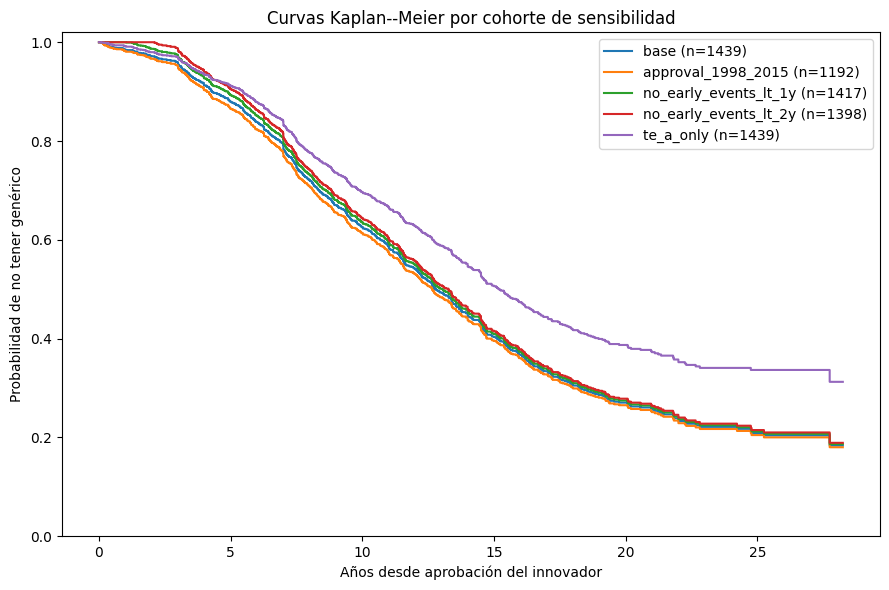

Figura guardada en: /Users/juanalbertomartinez/Desktop/Patente/figures/km_sensitivity_cohorts.png


,cohort,n_units,n_events,n_censored,event_rate,approval_year_min,approval_year_max,median_observed_time,median_events_only,km_median_time,n_has_patent,n_has_drug_substance_patent,n_has_drug_product_patent,n_has_exclusivity
0,base,1439,859,580,0.596942,1998,2018,10.313484,8.372348,12.791239,589,264,504,150
1,approval_1998_2015,1192,799,393,0.670302,1998,2015,11.540041,8.843258,12.657084,398,163,324,92
2,no_early_events_lt_1y,1417,837,580,0.590685,1998,2018,10.403833,8.594114,13.032170,587,264,502,150
3,no_early_events_lt_2y,1398,818,580,0.585122,1998,2018,10.468172,8.788501,13.273101,587,264,502,150
4,te_a_only,1439,711,728,0.494093,1998,2018,11.189596,8.714579,15.184120,589,264,504,150


In [10]:
# Curvas Kaplan--Meier para cohortes de sensibilidad

kmf = KaplanMeierFitter()

fig, ax = plt.subplots(figsize=(9, 6))

for name, df in sensitivity_cohorts.items():
    kmf.fit(
        durations=df["time_to_generic_years"],
        event_observed=df["event"],
        label=f"{name} (n={len(df)})"
    )
    kmf.plot_survival_function(ax=ax, ci_show=False)

ax.set_xlabel("Años desde aprobación del innovador")
ax.set_ylabel("Probabilidad de no tener genérico")
ax.set_title("Curvas Kaplan--Meier por cohorte de sensibilidad")
ax.set_ylim(0, 1.02)

plt.tight_layout()

fig_path = FIGURES_DIR / "km_sensitivity_cohorts.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {fig_path}")

display(sensitivity_cohort_summary)



La figura de sensibilidad se generó correctamente.

Las curvas muestran que la cohorte base, la cohorte 1998--2015 y las cohortes que excluyen eventos tempranos menores a 1 o 2 años tienen trayectorias muy similares. Esto sugiere que el comportamiento global del endpoint es relativamente estable frente a estas decisiones de filtrado.

La cohorte 1998--2015 tiene una tasa de eventos mayor, 67.0%, porque excluye productos más recientes que tienen menos tiempo de seguimiento. Sin embargo, su mediana Kaplan--Meier, aproximadamente 12.66 años, es muy cercana a la mediana de la cohorte base, aproximadamente 12.79 años. Esto indica que restringir el periodo para reducir censura reciente no altera de forma sustancial la estimación global.

Las cohortes sin eventos tempranos muestran un desplazamiento ligero hacia tiempos más largos:

- sin eventos menores a 1 año: mediana KM ≈ 13.03 años;
- sin eventos menores a 2 años: mediana KM ≈ 13.27 años.

Esto confirma que los eventos muy tempranos reducen moderadamente la mediana, pero no cambian radicalmente la curva.

La diferencia más clara aparece en la cohorte `te_a_only`. Esta curva se mantiene por encima de las demás durante buena parte del seguimiento, con una mediana Kaplan--Meier de aproximadamente 15.18 años. Esto ocurre porque la definición TE-A es más conservadora y reclasifica como censurados algunos eventos cuyo primer genérico no tenía TE code tipo `A`.

En conjunto, la sensibilidad sugiere dos conclusiones:

1. Los resultados globales son bastante robustos frente a la exclusión de eventos tempranos y al corte temporal 1998--2015.
2. La definición del evento basada en TE code sí cambia de forma importante la estimación del tiempo hasta genérico, por lo que debe reportarse como análisis de sensibilidad relevante.

## Modelos Cox estratificados por ruta en cohortes de sensibilidad

Ahora evaluaremos si la asociación entre patentes y entrada genérica se mantiene en las cohortes alternativas.

Para mantener consistencia con el notebook anterior, ajustaremos en cada cohorte un modelo Cox estratificado por `route_simplified`, con las covariables:

- `approval_year_centered`;
- `has_drug_substance_patent`;
- `has_drug_product_patent`;
- `has_patent_use_code`;
- `has_exclusivity`.

La variable `route_simplified` se usará como estrato, porque en el notebook anterior varias categorías de ruta mostraron posible violación del supuesto de riesgos proporcionales.

El objetivo de esta sección no es seleccionar un modelo final, sino revisar si los hazard ratios de las variables de patente son estables bajo distintas definiciones de cohorte.

In [11]:
# Modelos Cox estratificados por ruta en cohortes de sensibilidad

from lifelines import CoxPHFitter

def prepare_sensitivity_model_df(df):
    """
    Prepara una cohorte para el modelo Cox estratificado por ruta.
    """
    out = df.copy()
    
    # Variables binarias
    binary_cols = [
        "has_drug_substance_patent",
        "has_drug_product_patent",
        "has_patent_use_code",
        "has_exclusivity"
    ]
    
    for col in binary_cols:
        out[col] = out[col].fillna(False).astype(bool).astype(int)
    
    # Año centrado usando la misma referencia que antes: 2008
    out["approval_year_centered"] = out["approval_year"] - 2008
    
    # Ruta simplificada usando las mismas categorías principales del notebook anterior
    top_routes_fixed = [
        "ORAL",
        "INTRAVENOUS",
        "TOPICAL",
        "INHALATION",
        "INJECTION",
        "OPHTHALMIC",
        "SUBCUTANEOUS",
        "TRANSDERMAL"
    ]
    
    out["route_simplified"] = (
        out["route"]
        .fillna("UNKNOWN")
        .where(out["route"].fillna("UNKNOWN").isin(top_routes_fixed), "OTHER")
    )
    
    model_cols = [
        "time_to_generic_years",
        "event",
        "approval_year_centered",
        "has_drug_substance_patent",
        "has_drug_product_patent",
        "has_patent_use_code",
        "has_exclusivity",
        "route_simplified"
    ]
    
    return out[model_cols].dropna().copy()


def fit_stratified_cox_for_cohort(df, cohort_name):
    """
    Ajusta un Cox estratificado por ruta y devuelve resumen de variables principales.
    """
    model_df = prepare_sensitivity_model_df(df)
    
    cph = CoxPHFitter()
    cph.fit(
        model_df,
        duration_col="time_to_generic_years",
        event_col="event",
        strata=["route_simplified"]
    )
    
    summary = (
        cph.summary
        .reset_index()
        .rename(columns={"covariate": "variable"})
    )
    
    summary["cohort"] = cohort_name
    summary["n_units"] = len(model_df)
    summary["n_events"] = int(model_df["event"].sum())
    summary["concordance"] = cph.concordance_index_
    summary["partial_AIC"] = cph.AIC_partial_
    
    keep_cols = [
        "cohort",
        "variable",
        "coef",
        "exp(coef)",
        "se(coef)",
        "z",
        "p",
        "exp(coef) lower 95%",
        "exp(coef) upper 95%",
        "n_units",
        "n_events",
        "concordance",
        "partial_AIC"
    ]
    
    return summary[keep_cols], cph


sensitivity_model_summaries = []
sensitivity_models = {}

for cohort_name, df in sensitivity_cohorts.items():
    print("=" * 80)
    print(f"Ajustando modelo Cox estratificado: {cohort_name}")
    print("=" * 80)
    
    summary, model = fit_stratified_cox_for_cohort(df, cohort_name)
    
    sensitivity_model_summaries.append(summary)
    sensitivity_models[cohort_name] = model
    
    display(
        summary.loc[
            summary["variable"].isin([
                "has_drug_substance_patent",
                "has_drug_product_patent",
                "has_patent_use_code",
                "has_exclusivity"
            ]),
            [
                "cohort", "variable", "exp(coef)", "p",
                "exp(coef) lower 95%", "exp(coef) upper 95%",
                "n_units", "n_events", "concordance"
            ]
        ]
    )

sensitivity_model_summary = pd.concat(sensitivity_model_summaries, ignore_index=True)

print("=" * 80)
print("Resumen consolidado de modelos de sensibilidad")
print("=" * 80)

display(
    sensitivity_model_summary.loc[
        sensitivity_model_summary["variable"].isin([
            "has_drug_substance_patent",
            "has_drug_product_patent",
            "has_patent_use_code",
            "has_exclusivity"
        ]),
        [
            "cohort", "variable", "exp(coef)", "p",
            "exp(coef) lower 95%", "exp(coef) upper 95%",
            "n_units", "n_events", "concordance"
        ]
    ]
)

Ajustando modelo Cox estratificado: base


,cohort,variable,exp(coef),p,exp(coef) lower 95%,exp(coef) upper 95%,n_units,n_events,concordance
1,base,has_drug_substance_patent,0.628427,0.001481,0.471896,0.836880,1439,859,0.592713
2,base,has_drug_product_patent,0.734466,0.013759,0.574564,0.938870,1439,859,0.592713
3,base,has_patent_use_code,1.017755,0.882051,0.806636,1.284128,1439,859,0.592713
4,base,has_exclusivity,0.995667,0.976054,0.749856,1.322059,1439,859,0.592713


Ajustando modelo Cox estratificado: approval_1998_2015


,cohort,variable,exp(coef),p,exp(coef) lower 95%,exp(coef) upper 95%,n_units,n_events,concordance
1,approval_1998_2015,has_drug_substance_patent,0.564517,0.000515,0.408811,0.779528,1192,799,0.58346
2,approval_1998_2015,has_drug_product_patent,0.783709,0.066050,0.604354,1.016292,1192,799,0.58346
3,approval_1998_2015,has_patent_use_code,0.959565,0.742038,0.750475,1.226910,1192,799,0.58346
4,approval_1998_2015,has_exclusivity,1.241427,0.156989,0.920138,1.674903,1192,799,0.58346


Ajustando modelo Cox estratificado: no_early_events_lt_1y


...

,cohort,variable,exp(coef),p,exp(coef) lower 95%,exp(coef) upper 95%,n_units,n_events,concordance
1,no_early_events_lt_2y,has_drug_substance_patent,0.622915,0.001288,0.466930,0.831009,1398,818,0.587105
2,no_early_events_lt_2y,has_drug_product_patent,0.744524,0.020741,0.579825,0.956006,1398,818,0.587105
3,no_early_events_lt_2y,has_patent_use_code,1.078105,0.531793,0.851691,1.364710,1398,818,0.587105
4,no_early_events_lt_2y,has_exclusivity,1.026020,0.859746,0.771640,1.364259,1398,818,0.587105


Ajustando modelo Cox estratificado: te_a_only


,cohort,variable,exp(coef),p,exp(coef) lower 95%,exp(coef) upper 95%,n_units,n_events,concordance
1,te_a_only,has_drug_substance_patent,0.633362,0.006493,0.455848,0.880002,1439,711,0.570438
2,te_a_only,has_drug_product_patent,0.782588,0.082522,0.593400,1.032094,1439,711,0.570438
3,te_a_only,has_patent_use_code,0.967679,0.807333,0.743112,1.260110,1439,711,0.570438
4,te_a_only,has_exclusivity,1.040266,0.810912,0.752827,1.437454,1439,711,0.570438


Resumen consolidado de modelos de sensibilidad


,cohort,variable,exp(coef),p,exp(coef) lower 95%,exp(coef) upper 95%,n_units,n_events,concordance
1,base,has_drug_substance_patent,0.628427,0.001481,0.471896,0.836880,1439,859,0.592713
2,base,has_drug_product_patent,0.734466,0.013759,0.574564,0.938870,1439,859,0.592713
3,base,has_patent_use_code,1.017755,0.882051,0.806636,1.284128,1439,859,0.592713
4,base,has_exclusivity,0.995667,0.976054,0.749856,1.322059,1439,859,0.592713
6,approval_1998_2015,has_drug_substance_patent,0.564517,0.000515,0.408811,0.779528,1192,799,0.583460
7,approval_1998_2015,has_drug_product_patent,0.783709,0.066050,0.604354,1.016292,1192,799,0.583460
8,approval_1998_2015,has_patent_use_code,0.959565,0.742038,0.750475,1.226910,1192,799,0.583460
9,approval_1998_2015,has_exclusivity,1.241427,0.156989,0.920138,1.674903,1192,799,0.583460
11,no_early_events_lt_1y,has_drug_substance_patent,0.628383,0.001542,0.471344,0.837741,1417,837,0.590996
12,no_early_events_lt_1y,has_drug_product_patent,0.729223,0.012677,0.568892,0.934738,1417,837,0.590996




Los modelos Cox estratificados por ruta se ajustaron correctamente para todas las cohortes de sensibilidad.

El resultado más robusto es la asociación de `has_drug_substance_patent`. En todas las cohortes, el hazard ratio se mantiene claramente por debajo de 1:

- cohorte base: \(HR \approx 0.63\);
- cohorte 1998--2015: \(HR \approx 0.56\);
- sin eventos tempranos menores a 1 año: \(HR \approx 0.63\);
- sin eventos tempranos menores a 2 años: \(HR \approx 0.62\);
- TE-A only: \(HR \approx 0.63\).

Además, esta variable se mantiene estadísticamente significativa en todas las versiones. Esto sugiere que la asociación entre patente de sustancia y entrada más tardía de genéricos es estable frente a distintas definiciones de cohorte y evento.

La variable `has_drug_product_patent` también muestra hazard ratios menores que 1 en todas las cohortes, generalmente entre 0.73 y 0.78. Sin embargo, su significancia estadística es menos estable:

- es significativa en la cohorte base;
- es significativa al excluir eventos tempranos;
- queda en el límite o pierde significancia en la cohorte 1998--2015 y en la cohorte TE-A only.

Esto indica que la señal de patente de producto es consistente en dirección, pero más sensible a la definición de cohorte y evento.

Las variables `has_patent_use_code` y `has_exclusivity` no muestran asociaciones claras en ninguna cohorte. Sus hazard ratios se mantienen cercanos a 1 y los valores \(p\) son altos.

En conjunto, este análisis de sensibilidad refuerza la conclusión principal: las patentes de sustancia tienen la asociación más robusta con una entrada más tardía de genéricos. Las patentes de producto también parecen relevantes, aunque con evidencia más moderada. La exclusividad general y los códigos de uso de patente no muestran una señal consistente bajo estas especificaciones.

## Visualización de hazard ratios en cohortes de sensibilidad

Para resumir visualmente los resultados de sensibilidad, construiremos una figura con los hazard ratios de las dos variables principales de patente:

- `has_drug_substance_patent`;
- `has_drug_product_patent`.

La figura mostrará, para cada cohorte:

- hazard ratio estimado;
- intervalo de confianza del 95%;
- línea vertical en \(HR = 1\).

Esta visualización permitirá evaluar rápidamente si las estimaciones se mantienen en la misma dirección bajo distintas reglas de sensibilidad.

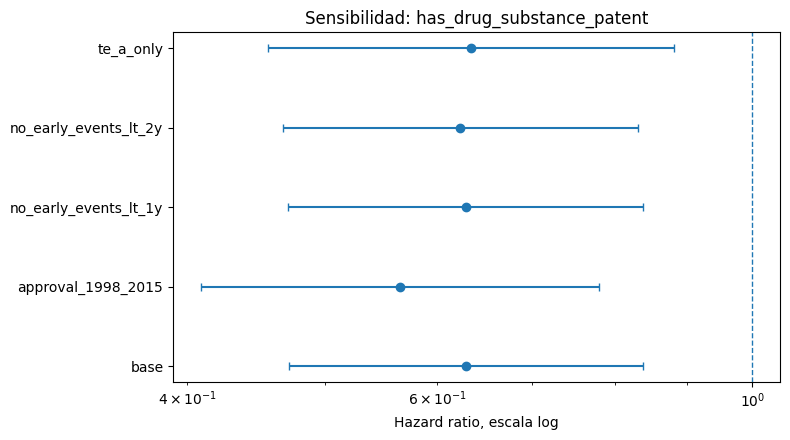

Figura guardada en: /Users/juanalbertomartinez/Desktop/Patente/figures/sensitivity_hr_has_drug_substance_patent.png


,cohort,variable,HR,HR_lower,HR_upper,p,n_units,n_events,concordance
1,base,has_drug_substance_patent,0.628427,0.471896,0.836880,0.001481,1439,859,0.592713
6,approval_1998_2015,has_drug_substance_patent,0.564517,0.408811,0.779528,0.000515,1192,799,0.583460
11,no_early_events_lt_1y,has_drug_substance_patent,0.628383,0.471344,0.837741,0.001542,1417,837,0.590996
16,no_early_events_lt_2y,has_drug_substance_patent,0.622915,0.466930,0.831009,0.001288,1398,818,0.587105
21,te_a_only,has_drug_substance_patent,0.633362,0.455848,0.880002,0.006493,1439,711,0.570438


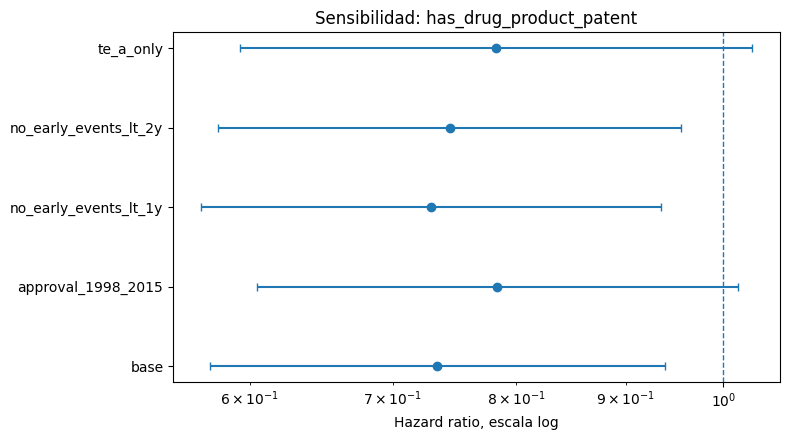

Figura guardada en: /Users/juanalbertomartinez/Desktop/Patente/figures/sensitivity_hr_has_drug_product_patent.png


,cohort,variable,HR,HR_lower,HR_upper,p,n_units,n_events,concordance
2,base,has_drug_product_patent,0.734466,0.574564,0.938870,0.013759,1439,859,0.592713
7,approval_1998_2015,has_drug_product_patent,0.783709,0.604354,1.016292,0.066050,1192,799,0.583460
12,no_early_events_lt_1y,has_drug_product_patent,0.729223,0.568892,0.934738,0.012677,1417,837,0.590996
17,no_early_events_lt_2y,has_drug_product_patent,0.744524,0.579825,0.956006,0.020741,1398,818,0.587105
22,te_a_only,has_drug_product_patent,0.782588,0.593400,1.032094,0.082522,1439,711,0.570438


In [12]:
# Visualización de hazard ratios en cohortes de sensibilidad

# Filtrar variables principales
plot_vars = [
    "has_drug_substance_patent",
    "has_drug_product_patent"
]

plot_df = sensitivity_model_summary.loc[
    sensitivity_model_summary["variable"].isin(plot_vars)
].copy()

plot_df = plot_df.rename(columns={
    "exp(coef)": "HR",
    "exp(coef) lower 95%": "HR_lower",
    "exp(coef) upper 95%": "HR_upper"
})

# Orden de cohortes
cohort_order = [
    "base",
    "approval_1998_2015",
    "no_early_events_lt_1y",
    "no_early_events_lt_2y",
    "te_a_only"
]

plot_df["cohort"] = pd.Categorical(
    plot_df["cohort"],
    categories=cohort_order,
    ordered=True
)

plot_df = plot_df.sort_values(["variable", "cohort"])

# Crear una figura por variable
for var in plot_vars:
    df_var = plot_df.loc[plot_df["variable"].eq(var)].copy()
    
    fig, ax = plt.subplots(figsize=(8, 4.5))
    
    y_pos = np.arange(len(df_var))
    
    ax.errorbar(
        df_var["HR"],
        y_pos,
        xerr=[
            df_var["HR"] - df_var["HR_lower"],
            df_var["HR_upper"] - df_var["HR"]
        ],
        fmt="o",
        capsize=3
    )
    
    ax.axvline(1, linestyle="--", linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_var["cohort"].astype(str))
    ax.set_xscale("log")
    ax.set_xlabel("Hazard ratio, escala log")
    ax.set_title(f"Sensibilidad: {var}")
    
    plt.tight_layout()
    
    fig_path = FIGURES_DIR / f"sensitivity_hr_{var}.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print(f"Figura guardada en: {fig_path}")
    
    display(
        df_var[
            [
                "cohort", "variable", "HR", "HR_lower", "HR_upper", "p",
                "n_units", "n_events", "concordance"
            ]
        ]
    )



Las figuras de sensibilidad se generaron correctamente y resumen de forma clara la estabilidad de las estimaciones.

Para `has_drug_substance_patent`, todos los hazard ratios se mantienen alrededor de 0.56--0.63 y todos los intervalos de confianza permanecen por debajo de 1. Esto confirma que la asociación entre patente de sustancia y menor hazard de entrada genérica es robusta bajo las reglas de sensibilidad evaluadas.

En términos prácticos, las unidades con patente de sustancia muestran una entrada de genéricos más tardía tanto en la cohorte base como en:

- la cohorte restringida a 1998--2015;
- la cohorte sin eventos menores a 1 año;
- la cohorte sin eventos menores a 2 años;
- la cohorte TE-A only.

Para `has_drug_product_patent`, la dirección del efecto también es estable: todos los hazard ratios son menores que 1. Sin embargo, los intervalos de confianza son más amplios y en algunas cohortes cruzan 1, especialmente en `approval_1998_2015` y `te_a_only`. Esto indica que la señal de patente de producto es consistente en dirección, pero menos robusta estadísticamente que la patente de sustancia.

En conjunto, estas figuras refuerzan una conclusión importante del análisis: la patente de sustancia es la variable regulatoria más establemente asociada con entrada tardía de genéricos. La patente de producto también parece asociarse con retraso, pero con mayor sensibilidad a la definición de cohorte y evento.

## Guardado de cohortes y resultados de sensibilidad

En esta última sección se guardarán las cohortes alternativas, las tablas resumen y los resultados de los modelos de sensibilidad.

Se guardarán:

- una versión `parquet` y una versión `csv` de cada cohorte;
- la tabla `sensitivity_cohort_summary`;
- la tabla `sensitivity_model_summary`.

Estas salidas permitirán documentar el análisis de sensibilidad y reutilizar las cohortes en reportes o notebooks posteriores.

In [13]:
# Guardar cohortes alternativas
for cohort_name, df in sensitivity_cohorts.items():
    parquet_path = SENSITIVITY_DIR / f"{cohort_name}.parquet"
    csv_path = SENSITIVITY_DIR / f"{cohort_name}.csv"
    
    df.to_parquet(parquet_path, index=False)
    df.to_csv(csv_path, index=False)


sensitivity_cohort_summary_path = TABLES_DIR / "sensitivity_cohort_summary.csv"
sensitivity_model_summary_path = TABLES_DIR / "sensitivity_model_summary.csv"

sensitivity_cohort_summary.to_csv(sensitivity_cohort_summary_path, index=False)
sensitivity_model_summary.to_csv(sensitivity_model_summary_path, index=False)

print("=" * 80)
print("Resultados de sensibilidad guardados correctamente")
print("=" * 80)

print("\nCohortes guardadas en:")
print(SENSITIVITY_DIR)

for cohort_name in sensitivity_cohorts.keys():
    print(f"- {cohort_name}.parquet")
    print(f"- {cohort_name}.csv")

print("\nTablas resumen:")
print(f"- {sensitivity_cohort_summary_path}")
print(f"- {sensitivity_model_summary_path}")

print("\nFiguras principales:")
print(f"- {FIGURES_DIR / 'km_sensitivity_cohorts.png'}")
print(f"- {FIGURES_DIR / 'sensitivity_hr_has_drug_substance_patent.png'}")
print(f"- {FIGURES_DIR / 'sensitivity_hr_has_drug_product_patent.png'}")

Resultados de sensibilidad guardados correctamente

Cohortes guardadas en:
/Users/juanalbertomartinez/Desktop/Patente/data_intermediate/sensitivity_cohorts
- base.parquet
- base.csv
- approval_1998_2015.parquet
- approval_1998_2015.csv
- no_early_events_lt_1y.parquet
- no_early_events_lt_1y.csv
- no_early_events_lt_2y.parquet
- no_early_events_lt_2y.csv
- te_a_only.parquet
- te_a_only.csv

Tablas resumen:
- /Users/juanalbertomartinez/Desktop/Patente/tables/sensitivity_cohort_summary.csv
- /Users/juanalbertomartinez/Desktop/Patente/tables/sensitivity_model_summary.csv

Figuras principales:
- /Users/juanalbertomartinez/Desktop/Patente/figures/km_sensitivity_cohorts.png
- /Users/juanalbertomartinez/Desktop/Patente/figures/sensitivity_hr_has_drug_substance_patent.png
- /Users/juanalbertomartinez/Desktop/Patente/figures/sensitivity_hr_has_drug_product_patent.png


Las cohortes guardadas fueron:

* `base`
* `approval_1998_2015`
* `no_early_events_lt_1y`
* `no_early_events_lt_2y`
* `te_a_only`

Se guardaron las tablas resumen:

* `sensitivity_cohort_summary.csv`
* `sensitivity_model_summary.csv`

y las figuras principales:

* `km_sensitivity_cohorts.png`
* `sensitivity_hr_has_drug_substance_patent.png`
* `sensitivity_hr_has_drug_product_patent.png`

Este notebook permitió evaluar la robustez del endpoint y de los efectos regulatorios principales.

Los resultados principales pueden resumirse así:

1. La cohorte base y las cohortes sin eventos tempranos tienen curvas Kaplan--Meier muy similares.
2. Excluir productos aprobados después de 2015 reduce la censura reciente, pero no cambia sustancialmente la mediana Kaplan--Meier.
3. La definición `TE-A only` es la sensibilidad que más cambia el endpoint, aumentando la mediana KM de aproximadamente 12.79 a 15.18 años.
4. La patente de sustancia mantiene una asociación robusta con entrada más tardía de genéricos en todas las cohortes.
5. La patente de producto mantiene la misma dirección del efecto, pero su significancia es menos estable.
6. La exclusividad general y los códigos de uso de patente no muestran una asociación consistente en estas especificaciones.

Con esto queda completada la fase del proyecto: validación preliminar del endpoint y sensibilidad de cohorte.